# Understanding Overfitting and Underfitting a Model

## Loading Dataset

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import io

sn.set_palette("tab10")

In [6]:
# If using Google colab uncomment this

from google.colab import files
uploaded = files.upload()

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
path = '/content/drive/MyDrive/Python/decision_tree/HR_comma_sep.csv'
hr_df = pd.read_csv(path)

In [23]:
hr_df.sample(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
5831,0.28,0.46,4,260,2,0,0,0,accounting,medium
12427,0.55,0.60,3,180,4,0,1,0,technical,medium
294,0.10,0.93,6,253,4,0,1,0,IT,medium
828,0.59,1.00,2,160,5,0,1,0,product_mng,low
5464,0.59,0.79,4,272,3,0,0,0,technical,low
12231,0.92,0.99,5,255,6,0,1,0,sales,low
13731,0.77,0.64,3,190,10,1,0,0,IT,medium
12060,0.85,0.91,5,226,5,0,1,0,management,medium
235,0.83,0.85,4,255,5,0,1,0,management,low
13665,0.20,0.59,6,113,3,0,0,0,management,high


In [24]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Encode Categorical Features

In [25]:
hr_encoded_df = pd.get_dummies(hr_df, columns=['dept', 'salary'])

In [26]:
hr_encoded_df.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept_IT,dept_RandD,...,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
5,0.41,0.50,2,153,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
6,0.10,0.77,6,247,4,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
7,0.92,0.85,5,259,5,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
8,0.89,1.00,5,224,5,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
9,0.42,0.53,2,142,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False


## Building a Decision Tree


### Setting X and y Values

In [27]:
X_features = list(hr_encoded_df.columns)
X_features.remove('left')

In [28]:
X_features

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'promotion_last_5years',
 'dept_IT',
 'dept_RandD',
 'dept_accounting',
 'dept_hr',
 'dept_management',
 'dept_marketing',
 'dept_product_mng',
 'dept_sales',
 'dept_support',
 'dept_technical',
 'salary_high',
 'salary_low',
 'salary_medium']

In [29]:
X = hr_encoded_df[X_features]
y = hr_encoded_df.left

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, \
y_train, y_test = train_test_split( X,
                                    y,
                                    test_size = 0.2,
                                    random_state = 23 )

In [32]:
X_train.shape

(11999, 20)

In [33]:
X_test.shape

(3000, 20)

### Build Decision Tree Model

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
tree = DecisionTreeClassifier(max_depth=1, criterion='gini')

In [36]:
tree.fit( X_train, y_train )

DecisionTreeClassifier(max_depth=1)

### Measuring Accuracy

In [37]:
from sklearn.metrics import roc_auc_score

### Predict on Train Data

In [38]:
y_train_pred_probs = tree.predict_proba(X_train)

In [39]:
roc_auc_score(y_train, y_train_pred_probs[:,1])

0.7836917702435501

### Predicting on Test Data

In [40]:
y_test_pred_probs = tree.predict_proba(X_test)

In [41]:
roc_auc_score(y_test, y_test_pred_probs[:,1])

0.7761934150011297

In [42]:
train_accuracy = []
test_accuracy = []

### Max Depth Vs Accuracy

In [43]:
for depth in range(1, 20):
    print(f"Building a model with depth: {depth}")

    tree_model = DecisionTreeClassifier(max_depth = depth, criterion = 'gini')
    tree_model.fit(X_train, y_train)

    train_probs = tree_model.predict_proba(X_train)
    train_accuracy.append(roc_auc_score(y_train, train_probs[:,1]))

    test_probs = tree_model.predict_proba(X_test)
    test_accuracy.append(roc_auc_score(y_test, test_probs[:,1]))

Building a model with depth: 1
Building a model with depth: 2
Building a model with depth: 3
Building a model with depth: 4
Building a model with depth: 5
Building a model with depth: 6
Building a model with depth: 7
Building a model with depth: 8
Building a model with depth: 9
Building a model with depth: 10
Building a model with depth: 11
Building a model with depth: 12
Building a model with depth: 13
Building a model with depth: 14
Building a model with depth: 15
Building a model with depth: 16
Building a model with depth: 17
Building a model with depth: 18
Building a model with depth: 19


In [44]:
acc_df = pd.DataFrame({"depth" : list(range(1, 20)),
                       "train_accuracy": train_accuracy,
                       "test_accuracy": test_accuracy})

In [45]:
acc_df

,depth,train_accuracy,test_accuracy
0,1,0.783692,0.776193
1,2,0.907888,0.909015
2,3,0.966509,0.965369
3,4,0.971782,0.971892
4,5,0.977162,0.975867
5,6,0.982361,0.981216
6,7,0.986456,0.986365
7,8,0.988545,0.983549
8,9,0.991009,0.983319
9,10,0.993405,0.980811


### Test Accuracy Vs Train Accuracy

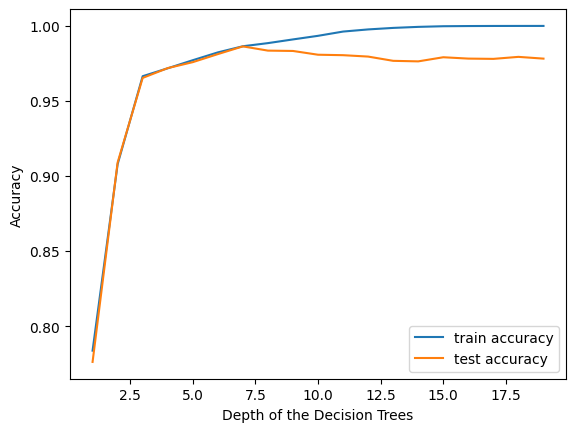

In [46]:
sn.lineplot(data = acc_df,
            x = 'depth',
            y = 'train_accuracy',
            label = 'train accuracy')
sn.lineplot(data = acc_df,
            x = 'depth',
            y = 'test_accuracy',
            label = 'test accuracy')
plt.xlabel('Depth of the Decision Trees')
plt.ylabel('Accuracy')
plt.legend();

## Finding Optimal Complexity: Max Depth

### Grid Search

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
params = {'max_depth': list(range(1, 20)),
          'criterion': ['gini', 'entropy']}

###Normally 5 or 10 (cross validation) depending on data size

In [49]:
tuning_grid = GridSearchCV(DecisionTreeClassifier(),
                           param_grid = params,
                           cv = 10,
                           scoring = 'roc_auc')

In [50]:
tuning_grid.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19]},
             scoring='roc_auc')

### Checking Search Results

In [51]:
grid_results = pd.DataFrame(tuning_grid.cv_results_)

In [52]:
grid_results[grid_results.rank_test_score < 10]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
5,0.028041,0.006151,0.008879,0.006815,gini,6,"{'criterion': 'gini', 'max_depth': 6}",0.980959,0.966287,0.984369,0.983719,0.979245,0.981970,0.978963,0.975381,0.979126,0.976158,0.978618,0.004951,4
24,0.023454,0.002911,0.004911,0.000584,entropy,6,"{'criterion': 'entropy', 'max_depth': 6}",0.986830,0.979996,0.987665,0.979841,0.983040,0.981597,0.981304,0.975650,0.971017,0.976492,0.980343,0.004792,2
25,0.025306,0.000779,0.004618,0.000242,entropy,7,"{'criterion': 'entropy', 'max_depth': 7}",0.986073,0.986213,0.983051,0.983511,0.979627,0.985936,0.985688,0.979052,0.975135,0.976813,0.982110,0.003938,1
26,0.028119,0.001660,0.005162,0.001272,entropy,8,"{'criterion': 'entropy', 'max_depth': 8}",0.979608,0.984596,0.983042,0.985359,0.971968,0.984452,0.985070,0.979304,0.972675,0.976856,0.980293,0.004821,3
27,0.030683,0.002407,0.004732,0.000428,entropy,9,"{'criterion': 'entropy', 'max_depth': 9}",0.965910,0.983863,0.982269,0.984511,0.972073,0.983546,0.983804,0.978197,0.972311,0.970018,0.977650,0.006600,9
28,0.031773,0.000756,0.004689,0.000258,entropy,10,"{'criterion': 'entropy', 'max_depth': 10}",0.970920,0.983571,0.981440,0.982847,0.973414,0.979848,0.986652,0.978504,0.973761,0.972206,0.978316,0.005163,5
29,0.033892,0.000814,0.004906,0.000637,entropy,11,"{'criterion': 'entropy', 'max_depth': 11}",0.970091,0.982187,0.985064,0.983641,0.975776,0.975180,0.988240,0.968680,0.975511,0.974341,0.977871,0.006212,6
30,0.035914,0.001886,0.004848,0.000857,entropy,12,"{'criterion': 'entropy', 'max_depth': 12}",0.964920,0.980712,0.987120,0.979785,0.977665,0.976185,0.987484,0.969344,0.977230,0.976953,0.977740,0.006588,7
31,0.036331,0.000496,0.004793,0.000264,entropy,13,"{'criterion': 'entropy', 'max_depth': 13}",0.973727,0.975157,0.987675,0.978740,0.978876,0.972609,0.986137,0.970618,0.976841,0.976889,0.977727,0.005224,8


In [53]:
grid_results[['param_criterion',
              'param_max_depth',
              'mean_test_score',
              'std_test_score',
              'rank_test_score']].sort_values('rank_test_score', ascending = True)[0:10]

,param_criterion,param_max_depth,mean_test_score,std_test_score,rank_test_score
25,entropy,7,0.982110,0.003938,1
24,entropy,6,0.980343,0.004792,2
26,entropy,8,0.980293,0.004821,3
5,gini,6,0.978618,0.004951,4
28,entropy,10,0.978316,0.005163,5
29,entropy,11,0.977871,0.006212,6
30,entropy,12,0.977740,0.006588,7
31,entropy,13,0.977727,0.005224,8
27,entropy,9,0.977650,0.006600,9
23,entropy,5,0.977174,0.004464,10


### Finding Best Params and Best Accuracy

In [54]:
tuning_grid.best_params_

{'criterion': 'entropy', 'max_depth': 7}

In [55]:
tuning_grid.best_score_

0.9821100211199042